In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbs
%matplotlib inline
plt.style.use('seaborn')

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

#  1. Data Load

In [5]:
diabets = load_diabetes()

# 2. Data EDA

In [7]:
dir(diabets)

['DESCR',
 'data',
 'data_filename',
 'feature_names',
 'frame',
 'target',
 'target_filename']

In [8]:
print(diabets.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

  :Number of Instances: 442

  :Number of Attributes: First 10 columns are numeric predictive values

  :Target: Column 11 is a quantitative measure of disease progression one year after baseline

  :Attribute Information:
      - age     age in years
      - sex
      - bmi     body mass index
      - bp      average blood pressure
      - s1      tc, T-Cells (a type of white blood cells)
      - s2      ldl, low-density lipoproteins
      - s3      hdl, high-density lipoproteins
      - s4      tch, thyroid stimulating hormone
      - s5      ltg, lamotrigine
      - s6      glu, blood sugar level

Note: Each of these 10 feature va

In [18]:
d_data = diabets.data

In [10]:
d_target = diabets.target

In [13]:
df = pd.DataFrame(diabets.data,columns=diabets.feature_names)

In [14]:
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019908,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068330,-0.092204
2,0.085299,0.050680,0.044451,-0.005671,-0.045599,-0.034194,-0.032356,-0.002592,0.002864,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022692,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031991,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018118,0.044485
439,0.041708,0.050680,-0.015906,0.017282,-0.037344,-0.013840,-0.024993,-0.011080,-0.046879,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044528,-0.025930


In [20]:
type(d_data)

numpy.ndarray

# 3. Data Split

In [23]:
x_train , x_test ,y_train, y_test = train_test_split(d_data,d_target,test_size=0.2,random_state=42)

# 4. Model

In [186]:
li = []

In [268]:
class LieanerRagression :
    def __init__(self,lr = 0.001):
        self.w = None 
        self.b = None
        self.lr = lr
        self.losses = []
        self.weight_his = []
        self.bais_his = []
    
    def forward(self,x):
        y_pred = np.sum(x*self.w) + self.b   # (x1w1 + x2w2+.....xnwn) + b
        return y_pred
    
    def loss(self,x,y):
        y_pred = self.forward(x)   
        return (y_pred-y)**2       # N으로 안 나눈 이유는 yi 한개의 데이터값에 대한 loss이기 때문이다.
        
    def gradient_descent(self,x,y):
        y_pred = self.forward(x)
        g = 2*x*(y_pred-y)     # y_pred를 앞으로 해놓으면 기울기 계산시 -x가 아닌 x가 되어 편하다
        b = 2*(y_pred-y)
        return g ,b
    
    def fit(self,x,y,epochs=100):
        self.w = np.ones(x.shape[1])      # x의 feature 만큼 w(1) 생성
        self.b = 0
        for epoch in range(epochs):      # epochs = w,b 업데이트 수 
            l = 0 
            w_grad = np.zeros(x.shape[1])
            b_grad = 0
            
            for X , Y in zip(x,y):
                l += self.loss(X,Y)                   # Loss 총 합
                w_i,b_i = self.gradient_descent(X,Y)  # 기울기 , 편향 벡터 feature 수만큼의 벡터가 있다.
                w_grad+=w_i                           # 전체 데이터 기울기 총합
                b_grad+=b_i                           # 전체 데이터 편향 총합
            
            self.w-=self.lr*(w_grad/len(y))           # w 업데이트
            self.b-=self.lr*(b_grad/len(y))           # b 업데이트
            print(f'epoch ({epoch+1}) ===> loss : {l/len(y):.5f}')
            self.losses.append(l/len(y)) #손실값 저장
            #li.append(self.w)
            self.weight_his.append(self.w) #weight 배열 저장
            self.bais_his.append(self.b) #bias값 저장
            
    def predict(self,x):
        y_pred = np.sum((x_test*model.w),axis=1)+model.b
        return y_pred
    
    def score(self,y_predict,y_test):
        score = np.sum((y_predict-y_test)**2)/len(y_predict)
        return score

In [269]:
model=LieanerRagression(lr=0.9)
model.fit(x_train,y_train,epochs=300)

epoch (1) ===> loss : 29690.32988
epoch (2) ===> loss : 21111.05142
epoch (3) ===> loss : 15596.49473
epoch (4) ===> loss : 12044.14051
epoch (5) ===> loss : 9748.31253
epoch (6) ===> loss : 8257.33047
epoch (7) ===> loss : 7282.08200
epoch (8) ===> loss : 6637.50538
epoch (9) ===> loss : 6205.13591
epoch (10) ===> loss : 5909.13421
epoch (11) ===> loss : 5700.94335
epoch (12) ===> loss : 5549.46875
epoch (13) ===> loss : 5434.79293
epoch (14) ===> loss : 5344.15274
epoch (15) ===> loss : 5269.36451
epoch (16) ===> loss : 5205.17613
epoch (17) ===> loss : 5148.21222
epoch (18) ===> loss : 5096.29904
epoch (19) ===> loss : 5048.03236
epoch (20) ===> loss : 5002.50088
epoch (21) ===> loss : 4959.10919
epoch (22) ===> loss : 4917.46443
epoch (23) ===> loss : 4877.30378
epoch (24) ===> loss : 4838.44800
epoch (25) ===> loss : 4800.77166
epoch (26) ===> loss : 4764.18416
epoch (27) ===> loss : 4728.61749
epoch (28) ===> loss : 4694.01840
epoch (29) ===> loss : 4660.34342
epoch (30) ===> los

epoch (270) ===> loss : 3031.44962
epoch (271) ===> loss : 3030.38643
epoch (272) ===> loss : 3029.33249
epoch (273) ===> loss : 3028.28772
epoch (274) ===> loss : 3027.25202
epoch (275) ===> loss : 3026.22532
epoch (276) ===> loss : 3025.20751
epoch (277) ===> loss : 3024.19852
epoch (278) ===> loss : 3023.19826
epoch (279) ===> loss : 3022.20665
epoch (280) ===> loss : 3021.22360
epoch (281) ===> loss : 3020.24903
epoch (282) ===> loss : 3019.28287
epoch (283) ===> loss : 3018.32503
epoch (284) ===> loss : 3017.37543
epoch (285) ===> loss : 3016.43400
epoch (286) ===> loss : 3015.50065
epoch (287) ===> loss : 3014.57532
epoch (288) ===> loss : 3013.65792
epoch (289) ===> loss : 3012.74838
epoch (290) ===> loss : 3011.84663
epoch (291) ===> loss : 3010.95259
epoch (292) ===> loss : 3010.06619
epoch (293) ===> loss : 3009.18737
epoch (294) ===> loss : 3008.31604
epoch (295) ===> loss : 3007.45214
epoch (296) ===> loss : 3006.59560
epoch (297) ===> loss : 3005.74635
epoch (298) ===> los

In [270]:
y_pred = model.predict(x_test)

In [271]:
model.score(y_pred,y_test)

2876.315978006173

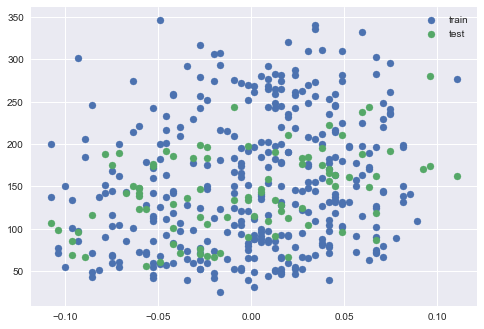

In [276]:
plt.scatter(x_train[:,0],y_train,label='train')
plt.scatter(x_test[:,0],y_pred,label='test')
plt.legend()